# PySpark SER Pipeline — Phase 2 : Conv1D Training

**Transition Spark → TensorFlow** — Entraînement d'un Conv1D

### Étapes du pipeline :
1. **Imports & Configuration**
2. **Chargement Parquet → NumPy** (vérification des 185 dimensions)
3. **Préparation du Tenseur** (StandardScaler, Reshape, One-Hot)
4. **Construction du Conv1D** (256 → 128 → 64 filtres, BatchNorm, Dropout 0.4)
5. **Entraînement avec Callbacks** (ReduceLROnPlateau, EarlyStopping)
6. **Évaluation & Diagnostic** (Courbes Accuracy/Loss, Matrice de Confusion)

### Pré-requis :
- Les fichiers `train_features.parquet` et `test_features.parquet` doivent avoir été générés par la Phase 1
- Vecteur de caractéristiques : **185 dimensions** (MFCC, ZCR, RMS, Spectral, Chroma, Mel, Entropy)

---
## Étape 1 — Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, BatchNormalization, MaxPooling1D,
    Flatten, Dense, Dropout, Input
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.utils import to_categorical

# --- Configuration ---
PARQUET_BASE = "/content/drive/MyDrive/Colab_OUTPUT"
TRAIN_PARQUET = os.path.join(PARQUET_BASE, "train_features.parquet")
TEST_PARQUET  = os.path.join(PARQUET_BASE, "test_features.parquet")

OUTPUT_DIR = "/content/drive/MyDrive/Colab_OUTPUT"
MODEL_PATH  = os.path.join(OUTPUT_DIR, "ser_conv1d_model.keras")
CURVES_PATH = os.path.join(OUTPUT_DIR, "training_curves.png")
CM_PATH     = os.path.join(OUTPUT_DIR, "confusion_matrix.png")

print(f"Train path: {TRAIN_PARQUET}")

FEATURE_DIM = 185
BATCH_SIZE  = 64
EPOCHS      = 100
DROPOUT     = 0.4
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow {tf.__version__}")
print(f"   GPU disponible : {tf.config.list_physical_devices('GPU')}")

Mounted at /content/drive
Train path: /content/drive/MyDrive/Colab_OUTPUT/train_features.parquet
TensorFlow 2.19.0
   GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Étape 2 — Chargement Parquet → NumPy

Chargement des fichiers Parquet générés par la Phase 1 (PySpark).
Vérification systématique que **chaque vecteur** fait exactement **185 dimensions**.

In [3]:
# --- Chargement ---
df_train = pd.read_parquet(TRAIN_PARQUET)
df_test  = pd.read_parquet(TEST_PARQUET)

print(f" Train : {len(df_train)} lignes, colonnes = {list(df_train.columns)}")
print(f" Test  : {len(df_test)} lignes,  colonnes = {list(df_test.columns)}")

 Train : 38720 lignes, colonnes = ['path', 'label', 'augmentation', 'features']
 Test  : 2482 lignes,  colonnes = ['path', 'label', 'augmentation', 'features']


In [4]:
# --- Extraction features → NumPy ---
X_train = np.vstack(df_train["features"].values)
X_test  = np.vstack(df_test["features"].values)

y_train_labels = df_train["label"].values
y_test_labels  = df_test["label"].values

# --- Vérification de la taille des vecteurs ---
print(f" Vérification des dimensions :")
print(f"   X_train shape : {X_train.shape}")
print(f"   X_test  shape : {X_test.shape}")

assert X_train.shape[1] == FEATURE_DIM, \
    f" Train: attendu {FEATURE_DIM} features, obtenu {X_train.shape[1]}"
assert X_test.shape[1] == FEATURE_DIM, \
    f" Test: attendu {FEATURE_DIM} features, obtenu {X_test.shape[1]}"

# Vérifier chaque vecteur individuellement
train_lens = np.array([len(f) for f in df_train["features"].values])
test_lens  = np.array([len(f) for f in df_test["features"].values])
assert np.all(train_lens == FEATURE_DIM), \
    f" Vecteurs train incohérents : min={train_lens.min()}, max={train_lens.max()}"
assert np.all(test_lens == FEATURE_DIM), \
    f" Vecteurs test incohérents : min={test_lens.min()}, max={test_lens.max()}"

print(f"    Tous les vecteurs ont exactement {FEATURE_DIM} dimensions")

 Vérification des dimensions :
   X_train shape : (38720, 185)
   X_test  shape : (2482, 185)
    Tous les vecteurs ont exactement 185 dimensions


In [5]:
# --- Distribution des labels ---
print(" Distribution des labels (Train) :")
for label, count in zip(*np.unique(y_train_labels, return_counts=True)):
    print(f"   {label:>10s} : {count}")

print(f"\n Distribution des labels (Test) :")
for label, count in zip(*np.unique(y_test_labels, return_counts=True)):
    print(f"   {label:>10s} : {count}")

# Libérer les DataFrames Pandas
del df_train, df_test

 Distribution des labels (Train) :
        angry : 6072
      disgust : 6220
         fear : 6204
        happy : 6108
      neutral : 5812
           ps : 1236
          sad : 6248
     surprise : 820

 Distribution des labels (Test) :
        angry : 405
      disgust : 368
         fear : 372
        happy : 396
      neutral : 442
           ps : 91
          sad : 361
     surprise : 47


---
##  Étape 3 — Préparation du Tenseur

| Opération | Détail |
|-----------|--------|
| **StandardScaler** | `fit()` sur le train uniquement, `transform()` sur train + test |
| **Reshape** | `(n, 185)` → `(n, 185, 1)` pour l'entrée Conv1D |
| **One-Hot Encoding** | `LabelEncoder` + `to_categorical()` → 8 classes |

In [6]:
# --- StandardScaler (fit sur train, transform sur les deux) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Vérification post-scaling
assert not np.any(np.isnan(X_train)), " NaN détectés dans X_train après scaling"
assert not np.any(np.isinf(X_train)), " Inf détectés dans X_train après scaling"
assert not np.any(np.isnan(X_test)),  " NaN détectés dans X_test après scaling"
assert not np.any(np.isinf(X_test)),  " Inf détectés dans X_test après scaling"
print(" StandardScaler appliqué — pas de NaN/Inf")

# --- Reshape pour Conv1D : (batch, 185) → (batch, 185, 1) ---
X_train = X_train.reshape(-1, FEATURE_DIM, 1)
X_test  = X_test.reshape(-1, FEATURE_DIM, 1)
print(f" Reshape : X_train={X_train.shape}, X_test={X_test.shape}")

# --- Encodage des labels → One-Hot ---
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_labels)
y_test_enc  = le.transform(y_test_labels)

NUM_CLASSES = len(le.classes_)
y_train = to_categorical(y_train_enc, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_enc,  num_classes=NUM_CLASSES)

print(f" One-Hot Encoding : {NUM_CLASSES} classes → {list(le.classes_)}")
print(f"   y_train shape : {y_train.shape}")
print(f"   y_test  shape : {y_test.shape}")

# Cohérence
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0]  == y_test.shape[0]

 StandardScaler appliqué — pas de NaN/Inf
 Reshape : X_train=(38720, 185, 1), X_test=(2482, 185, 1)
 One-Hot Encoding : 8 classes → ['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad', 'surprise']
   y_train shape : (38720, 8)
   y_test  shape : (2482, 8)


---
## Étape 4 — Construction du Conv1D (Architecture Babko-Optimisée)

```
Input: (185, 1)
├── Conv1D(256, kernel=5, relu) + BatchNorm + MaxPool1D(5)
├── Conv1D(128, kernel=5, relu) + BatchNorm + MaxPool1D(5)
├── Conv1D(64,  kernel=5, relu) + BatchNorm + MaxPool1D(5)
├── Flatten
├── Dense(256, relu) + BatchNorm + Dropout(0.4)
├── Dense(128, relu) + BatchNorm + Dropout(0.4)
└── Dense(NUM_CLASSES, softmax)
```

In [7]:
model = Sequential([
    Input(shape=(FEATURE_DIM, 1)),

    # --- Bloc Conv 1 : 256 filtres ---
    Conv1D(256, kernel_size=5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=5),

    # --- Bloc Conv 2 : 128 filtres ---
    Conv1D(128, kernel_size=5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=5),

    # --- Bloc Conv 3 : 64 filtres ---
    Conv1D(64, kernel_size=5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=5),

    # --- Couches denses ---
    Flatten(),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(DROPOUT),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(DROPOUT),

    Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

# Estimation mémoire
total_params = model.count_params()
mem_mb = (total_params * 4) / (1024 ** 2)
print(f"\ Estimation mémoire modèle : {mem_mb:.1f} MB ({total_params:,} paramètres)")

<>:44: SyntaxWarning: invalid escape sequence '\ '
<>:44: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_10012/4174614804.py:44: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Estimation mémoire modèle : {mem_mb:.1f} MB ({total_params:,} paramètres)")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 185, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 185, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 37, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 37, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 37, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7, 64)          │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,424 (1017.28 KB)

 Trainable params: 258,760 (1010.78 KB)

 Non-trainable params: 1,664 (6.50 KB)

\ Estimation mémoire modèle : 1.0 MB (260,424 paramètres)


---
## Étape 5 — Entraînement avec Callbacks

| Callback | Paramètres |
|----------|------------|
| **ReduceLROnPlateau** | `monitor='val_loss'`, `factor=0.5`, `patience=5`, `min_lr=1e-6` |
| **EarlyStopping** | `monitor='val_loss'`, `patience=10`, `restore_best_weights=True` |

In [8]:
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
]

print(f" Lancement de l'entraînement")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Max epochs : {EPOCHS}")
print(f"   Train size : {X_train.shape[0]}, Val size : {X_test.shape[0]}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

 Lancement de l'entraînement
   Batch size : 64
   Max epochs : 100
   Train size : 38720, Val size : 2482
Epoch 1/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.4144 - loss: 1.5919 - val_accuracy: 0.4774 - val_loss: 1.3259 - learning_rate: 0.0010
Epoch 2/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5154 - loss: 1.2320 - val_accuracy: 0.5379 - val_loss: 1.1603 - learning_rate: 0.0010
Epoch 3/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5526 - loss: 1.1362 - val_accuracy: 0.5492 - val_loss: 1.1183 - learning_rate: 0.0010
Epoch 4/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5693 - loss: 1.0956 - val_accuracy: 0.5326 - val_loss: 1.1834 - learning_rate: 0.0010
Epoch 5/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5857 - loss: 1.0592 - val_accuracy: 0.4923 - val_loss: 1.3406 - learning_rate: 0.0010
Epoch 6/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5970 - loss: 1.0316 - val_accuracy: 0.5161 - val_loss: 1.235

---
##  Étape 6 — Évaluation & Diagnostic

In [9]:
# --- Score sur le test set ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss     : {test_loss:.4f}")
print(f" Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

# --- Classification Report ---
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print(f"\n Classification Report :")
print(classification_report(
    y_true_classes, y_pred_classes,
    target_names=le.classes_,
    digits=3,
))

 Test Loss     : 1.0706
 Test Accuracy : 0.5955 (59.55%)

 Classification Report :
              precision    recall  f1-score   support

       angry      0.784     0.635     0.701       405
     disgust      0.638     0.389     0.483       368
        fear      0.661     0.457     0.541       372
       happy      0.426     0.636     0.510       396
     neutral      0.531     0.767     0.628       442
          ps      0.988     0.923     0.955        91
         sad      0.669     0.571     0.616       361
    surprise      0.540     0.574     0.557        47

    accuracy                          0.595      2482
   macro avg      0.655     0.619     0.624      2482
weighted avg      0.628     0.595     0.595      2482



### Courbes Accuracy / Loss

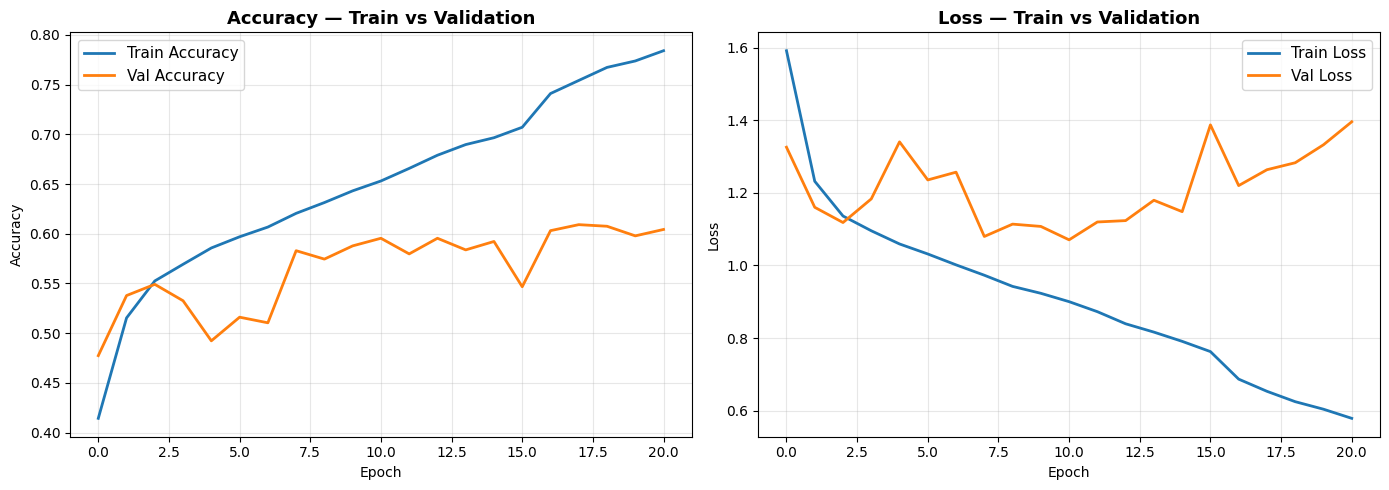

 Courbes sauvegardées → /content/drive/MyDrive/Colab_OUTPUT/training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],    label="Train Accuracy", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy",   linewidth=2)
axes[0].set_title("Accuracy — Train vs Validation", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss", linewidth=2)
axes[1].plot(history.history["val_loss"],  label="Val Loss",   linewidth=2)
axes[1].set_title("Loss — Train vs Validation", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f" Courbes sauvegardées → {CURVES_PATH}")

### Matrice de Confusion

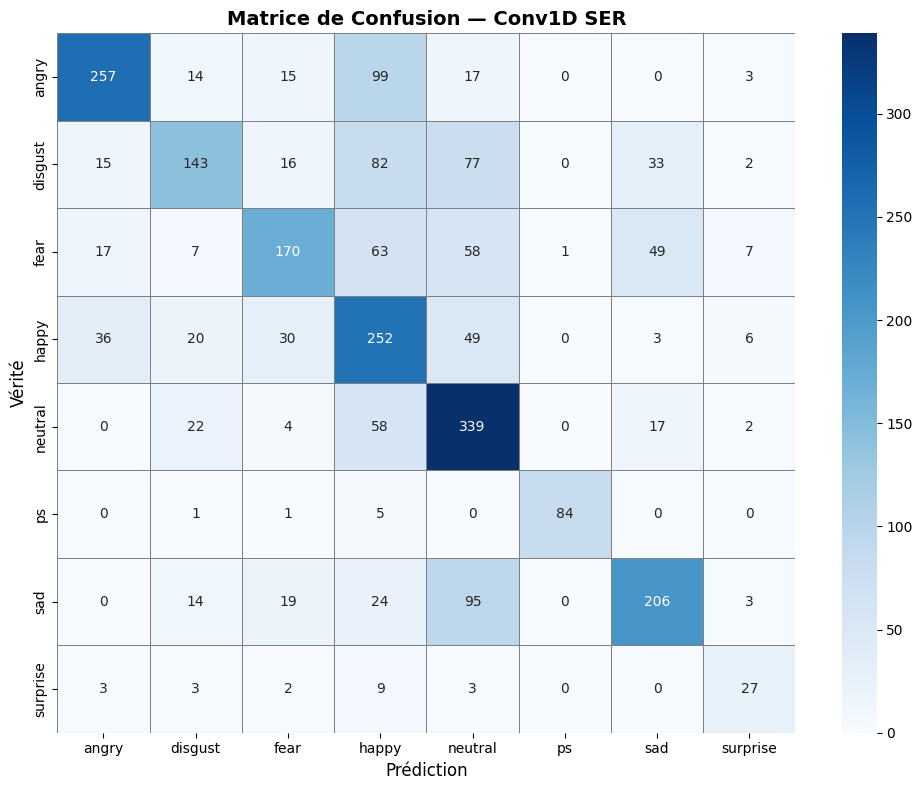

 Matrice de confusion sauvegardée → /content/drive/MyDrive/Colab_OUTPUT/confusion_matrix.png


In [11]:
cm = confusion_matrix(y_true_classes, y_pred_classes)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
    linewidths=0.5,
    linecolor="gray",
)
ax.set_title("Matrice de Confusion — Conv1D SER", fontsize=14, fontweight="bold")
ax.set_xlabel("Prédiction", fontsize=12)
ax.set_ylabel("Vérité", fontsize=12)
plt.tight_layout()
plt.savefig(CM_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f" Matrice de confusion sauvegardée → {CM_PATH}")

---
## Sauvegarde du modèle

In [12]:
model.save(MODEL_PATH)
print(f" Modèle sauvegardé → {MODEL_PATH}")

# --- Résumé final ---
stopped_epoch = len(history.history["loss"])
best_val_loss = min(history.history["val_loss"])
best_val_acc  = max(history.history["val_accuracy"])

print(f"\n{'=' * 50}")
print(f" PIPELINE PHASE 2 TERMINÉE")
print(f"{'=' * 50}")
print(f"   Epochs effectués   : {stopped_epoch}/{EPOCHS}")
print(f"   Meilleur val_loss  : {best_val_loss:.4f}")
print(f"   Meilleur val_acc   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Test accuracy      : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Modèle             : {MODEL_PATH}")
print(f"   Courbes            : {CURVES_PATH}")
print(f"   Matrice confusion  : {CM_PATH}")

 Modèle sauvegardé → /content/drive/MyDrive/Colab_OUTPUT/ser_conv1d_model.keras

 PIPELINE PHASE 2 TERMINÉE
   Epochs effectués   : 21/100
   Meilleur val_loss  : 1.0706
   Meilleur val_acc   : 0.6092 (60.92%)
   Test accuracy      : 0.5955 (59.55%)
   Modèle             : /content/drive/MyDrive/Colab_OUTPUT/ser_conv1d_model.keras
   Courbes            : /content/drive/MyDrive/Colab_OUTPUT/training_curves.png
   Matrice confusion  : /content/drive/MyDrive/Colab_OUTPUT/confusion_matrix.png
